 ### Bagging.
In this exercise, we will numerically estimate the probability that a given observation is part of a bootstrap sample (reference: Sec. 5.2 and 5.4, ISLP).

Generate a set $𝒟$ of $n=1,000$ random Gaussian observations and tag observation $j=4$. Generate 200 bootstrapped samples $\mathscr{D}^{(i)},i=1,2,…,200$, from this set and find the fraction of bootstrapped samples that do not contain the tagged observation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up random number generator with fixed seed for reproducibility
rng = np.random.default_rng(42)

# Generate 1,000 random Gaussian observations
n = 1000
D = rng.normal(0, 1, n)

# Tag observation j=4
tag = D[4]

# Generate 200 bootstrapped samples
num_bootstraps = 200
samples_without_tagged = 0

for _ in range(num_bootstraps):
    # Generate bootstrap sample with replacement
    bootstrap_samples = np.random.choice(D, size=n, replace=True)
    
    # Check if the tagged index j is NOT in the bootstrap sample
    if tag not in bootstrap_samples:
        samples_without_tagged += 1

# Calculate the fraction of bootstrapped samples that do not contain the tagged observation
fraction_not_containing = samples_without_tagged / num_bootstraps

print(f"Fraction of bootstrapped samples that do not contain the tagged observation: {fraction_not_containing:.4f}")

Fraction of bootstrapped samples that do not contain the tagged observation: 0.4100


Using the above procedure, create a plot that displays, for each integer value $n$ from $100$ to $100,000$, the fraction of bootstrapped samples that contain the tagged $(j^{th})$ observation.

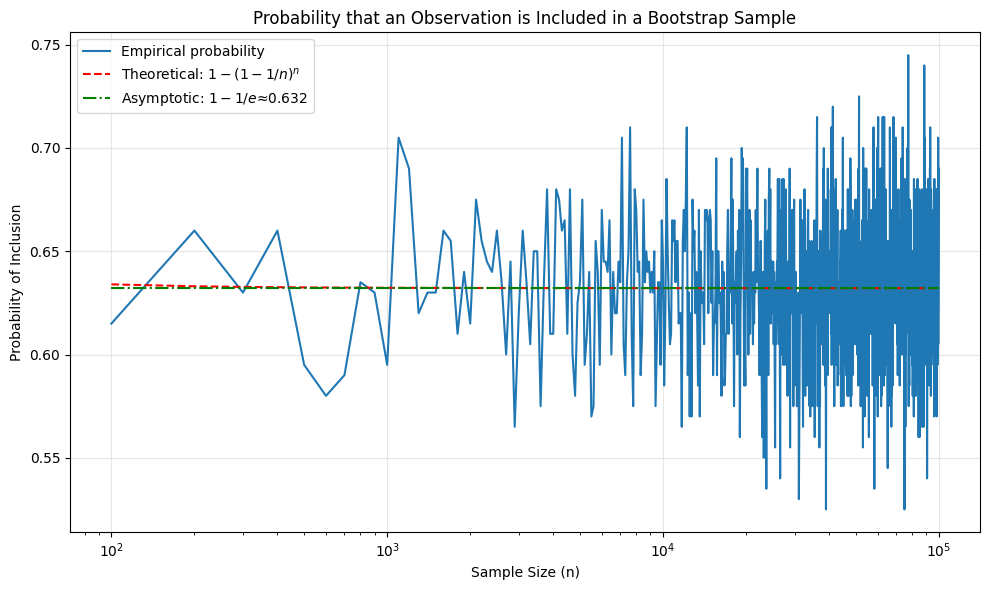

In [7]:
fraction_containing = []
n_values = range(100, 100000, 100)

for n in n_values:
    D = rng.normal(0, 1, n)
    tag = D[4]
    
    num_bootstraps = 200
    samples_containing_tagged = 0
    
    for _ in range(num_bootstraps):
       # Generate bootstrap sample with replacement
        bootstrap_samples = np.random.choice(D, size=n, replace=True)
        
        # Check if the tagged index j is in the bootstrap sample
        if tag in bootstrap_samples:
            samples_containing_tagged += 1
        
    # Calculate the fraction of bootstrapped samples that contain the tagged observation
    fraction = samples_containing_tagged / num_bootstraps
    fraction_containing.append(fraction)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(n_values, fraction_containing, label='Empirical probability')
plt.plot(n_values, [1 - (1 - 1/n)**n for n in n_values], 'r--', label='Theoretical: $1 - (1 - 1/n)^n$')
plt.plot(n_values, [1 - 1/np.e for _ in n_values], 'g-.', label='Asymptotic: $1 - 1/e ≈ 0.632$')

plt.xscale('log')
plt.xlabel('Sample Size (n)')
plt.ylabel('Probability of Inclusion')
plt.title('Probability that an Observation is Included in a Bootstrap Sample')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Given that $\lim\limits_{n\rightarrow\infty}{\left(1-\frac{1}{n}\right)^n}=\frac{1}{e}$, comment on what your plot in Part b. above looks like in for large values of $n$.

For large values of $n$, the probability of a bootstrap sample including the tagged value approaches $1-\frac{1}{e}$. The convergence is not clear from the empirical data alone, as the sampling variance from using a small number of boostrap samples is orders of magnitute greater than the difference between $1-{\left(1-\frac{1}{n}\right)^n}$ and $1-\frac{1}{e}$. I've included the theoritcal fraction at each dataset size to show to difference between the theoretical value and the asymptotic value, since it is not apparent in the emperical data.